# Exploring Vectorizations of Zigzag Persistence Diagrams

This notebook evaluates different vectorization methods on the zigzag persistence
diagrams computed from 3D neural activity grids. The goal is to select the best
vectorization(s) for downstream tasks (classification, regression, clustering).

**Vectorizations tested:**

*Standard (from persistence diagram):*
- `PersistenceImage` — 2D histogram in birth–persistence plane
- `PersistenceLandscape` — piecewise-linear envelopes
- `Silhouette` — weighted tent functions
- `BettiCurve` — count of alive bars at each scale
- `PersistenceEntropy` — Shannon entropy of persistence distribution
- `PersistenceStatistics` — summary statistics (9 features per dimension)

*Zigzag-specific (temporal structure):*
- `BettiProfile` — Betti number at each frame
- `BirthFrequency` — relative birth frequency per frame
- `PersistenceProfile` — mean persistence of alive bars per frame
- `TurnoverRate` — topological event rate per frame
- `EffectivePersistenceImage` — PI weighted by birth frequency
- `CumulativePersistence` — cumulative total persistence over frames

In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from scipy.spatial.distance import pdist, squareform

from zztop.vectorizations import (
    # Standard vectorizations
    PersistenceImage,
    PersistenceLandscape,
    Silhouette,
    BettiCurve,
    PersistenceEntropy,
    PersistenceStatistics,
    # Zigzag-specific vectorizations
    BettiProfile,
    BirthFrequency,
    PersistenceProfile,
    TurnoverRate,
    EffectivePersistenceImage,
    CumulativePersistence,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Load computed zigzag barcodes

In [ ]:
DATA_ROOT = Path(
    "/orfeo/scratch/area/ygardinazzi/sensorium_2026/derivatives/grid-15x15x10_norm-by_minmax"
)

# ============================================================
# CONFIGURATION: Set the p_active value used in the batch run
# ============================================================
P_ACTIVE = 30  # Must match the batch run
PER_TRIAL_THRESH = True  # Whether to use per-trial thresholding (True) or global thresholding (False)
if PER_TRIAL_THRESH: 
    ZZ_FOLDER = f"trials_zz-thresh-{P_ACTIVE}-per-trial"
else:
    ZZ_FOLDER = f"trials_zz-thresh-{P_ACTIVE}"

mice = sorted([d.name for d in DATA_ROOT.iterdir()
               if d.is_dir() and d.name.startswith("dynamic")])
print(f"Found {len(mice)} mice")

# Check which mice have zigzag results
for m in mice:
    zz_dir = DATA_ROOT / m / ZZ_FOLDER
    if zz_dir.is_dir():
        n_files = len(list(zz_dir.glob("*.npy")))
        print(f"  {m[:40]}...: {n_files} barcode files")
    else:
        print(f"  {m[:40]}...: NO zigzag results yet")

Found 10 mice
  dynamic29156-11-10-Video-8744edeac3b4d1c...: 720 barcode files
  dynamic29228-2-10-Video-8744edeac3b4d1ce...: 704 barcode files
  dynamic29234-6-9-Video-8744edeac3b4d1ce1...: 729 barcode files
  dynamic29513-3-5-Video-8744edeac3b4d1ce1...: 714 barcode files
  dynamic29514-2-9-Video-8744edeac3b4d1ce1...: 723 barcode files
  dynamic29515-10-12-Video-9b4f6a1a067fe51...: 445 barcode files
  dynamic29623-4-9-Video-9b4f6a1a067fe51e1...: 420 barcode files
  dynamic29647-19-8-Video-9b4f6a1a067fe51e...: 444 barcode files
  dynamic29712-5-9-Video-9b4f6a1a067fe51e1...: 461 barcode files
  dynamic29755-2-8-Video-9b4f6a1a067fe51e1...: 450 barcode files


In [3]:
def load_zigzag_barcodes(mouse_name, max_trials=None):
    """Load zigzag barcode .npy files for a mouse.
    
    Returns
    -------
    barcodes : list of list of (dim, birth, death)
    trial_names : list of str
    """
    zz_dir = DATA_ROOT / mouse_name / ZZ_FOLDER
    files = sorted(zz_dir.glob("zz-thresh-*.npy"))
    # Exclude the info.json-named files
    files = [f for f in files if "info" not in f.name]
    
    if max_trials is not None:
        # Sample evenly
        indices = np.linspace(0, len(files) - 1, min(max_trials, len(files)), dtype=int)
        files = [files[i] for i in indices]
    
    barcodes = []
    trial_names = []
    for f in files:
        raw = np.load(f, allow_pickle=True)
        # Convert to list of tuples — vectorizers require this format
        bars = [tuple(row) for row in raw]
        barcodes.append(bars)
        trial_names.append(f.stem)
    
    return barcodes, trial_names

In [4]:
# Load barcodes from the first mouse with results
REF_MOUSE = None
for m in mice:
    zz_dir = DATA_ROOT / m / ZZ_FOLDER
    if zz_dir.is_dir() and len(list(zz_dir.glob("*.npy"))) > 10:
        REF_MOUSE = m
        break

if REF_MOUSE is None:
    raise RuntimeError(
        f"No mouse has zigzag results in {ZZ_FOLDER}. "
        "Run the batch script first."
    )

print(f"Using mouse: {REF_MOUSE}")
barcodes, trial_names = load_zigzag_barcodes(REF_MOUSE, max_trials=100)
print(f"Loaded {len(barcodes)} barcodes")

# Quick sanity check
for i in range(min(3, len(barcodes))):
    bars = barcodes[i]
    print(f"  {trial_names[i]}: {len(bars)} bars, type={type(bars[0]) if bars else 'empty'}")

Using mouse: dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce


Loaded 100 barcodes
  zz-thresh-30_grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-0: 140457 bars, type=<class 'tuple'>
  zz-thresh-30_grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-105: 149323 bars, type=<class 'tuple'>
  zz-thresh-30_grid-15x15x10_norm-by_minmax_rec-dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce_trial-112: 170249 bars, type=<class 'tuple'>


## 2. Standard vectorizations

Apply each standard vectorization to all loaded barcodes and inspect the
resulting feature matrices.

In [5]:
# Define vectorizers with a few parameter variants
vectorizers = {
    # --- Standard ---
    "PI_20x20_s1": PersistenceImage(resolution=(20, 20), sigma=1.0),
    "PI_20x20_s2": PersistenceImage(resolution=(20, 20), sigma=2.0),
    "PI_30x30_s1": PersistenceImage(resolution=(30, 30), sigma=1.0),
    "Landscape_5": PersistenceLandscape(n_landscapes=5, resolution=100),
    "Landscape_10": PersistenceLandscape(n_landscapes=10, resolution=100),
    "Silhouette_p1": Silhouette(resolution=100, power=1.0),
    "Silhouette_p2": Silhouette(resolution=100, power=2.0),
    "BettiCurve_100": BettiCurve(resolution=100),
    "BettiCurve_200": BettiCurve(resolution=200),
    "Entropy": PersistenceEntropy(normalize=True),
    "Statistics": PersistenceStatistics(),
    # --- Zigzag-specific ---
    "BettiProfile": BettiProfile(),
    "BirthFreq": BirthFrequency(),
    "PersProfile": PersistenceProfile(),
    "Turnover": TurnoverRate(),
    "EffPI": EffectivePersistenceImage(),
    "CumPers": CumulativePersistence(),
}

In [6]:
# Apply all vectorizations
features = {}

for name, vec in vectorizers.items():
    try:
        X = vec.fit_transform(barcodes)
        # Ensure 2D
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        features[name] = X
        n_finite = np.isfinite(X).all(axis=1).sum()
        print(f"  {name:>20s}: shape={str(X.shape):>15s}, "
              f"finite={n_finite}/{len(X)}, "
              f"range=[{np.nanmin(X):.4f}, {np.nanmax(X):.4f}]")
    except Exception as e:
        print(f"  {name:>20s}: FAILED — {e}")

           PI_20x20_s1: shape=    (100, 1200), finite=100/100, range=[0.0000, 9022.0926]
           PI_20x20_s2: shape=    (100, 1200), finite=100/100, range=[0.0000, 5924.3694]
           PI_30x30_s1: shape=    (100, 2700), finite=100/100, range=[0.0000, 5422.3917]
           Landscape_5: shape=    (100, 1500), finite=100/100, range=[0.0000, 160.3636]
          Landscape_10: shape=    (100, 3000), finite=100/100, range=[0.0000, 160.3636]
         Silhouette_p1: shape=     (100, 300), finite=100/100, range=[0.0000, 49.7782]
         Silhouette_p2: shape=     (100, 300), finite=100/100, range=[0.0000, 81.7755]
        BettiCurve_100: shape=     (100, 300), finite=100/100, range=[0.0000, 1692.0000]
        BettiCurve_200: shape=     (100, 600), finite=100/100, range=[0.0000, 1712.0000]
               Entropy: shape=       (100, 3), finite=100/100, range=[0.7932, 0.9521]
            Statistics: shape=      (100, 27), finite=100/100, range=[0.1053, 119400.0000]
          BettiProfile: shap

## 3. Visualize feature matrices

Heatmaps and example feature vectors for each vectorization.

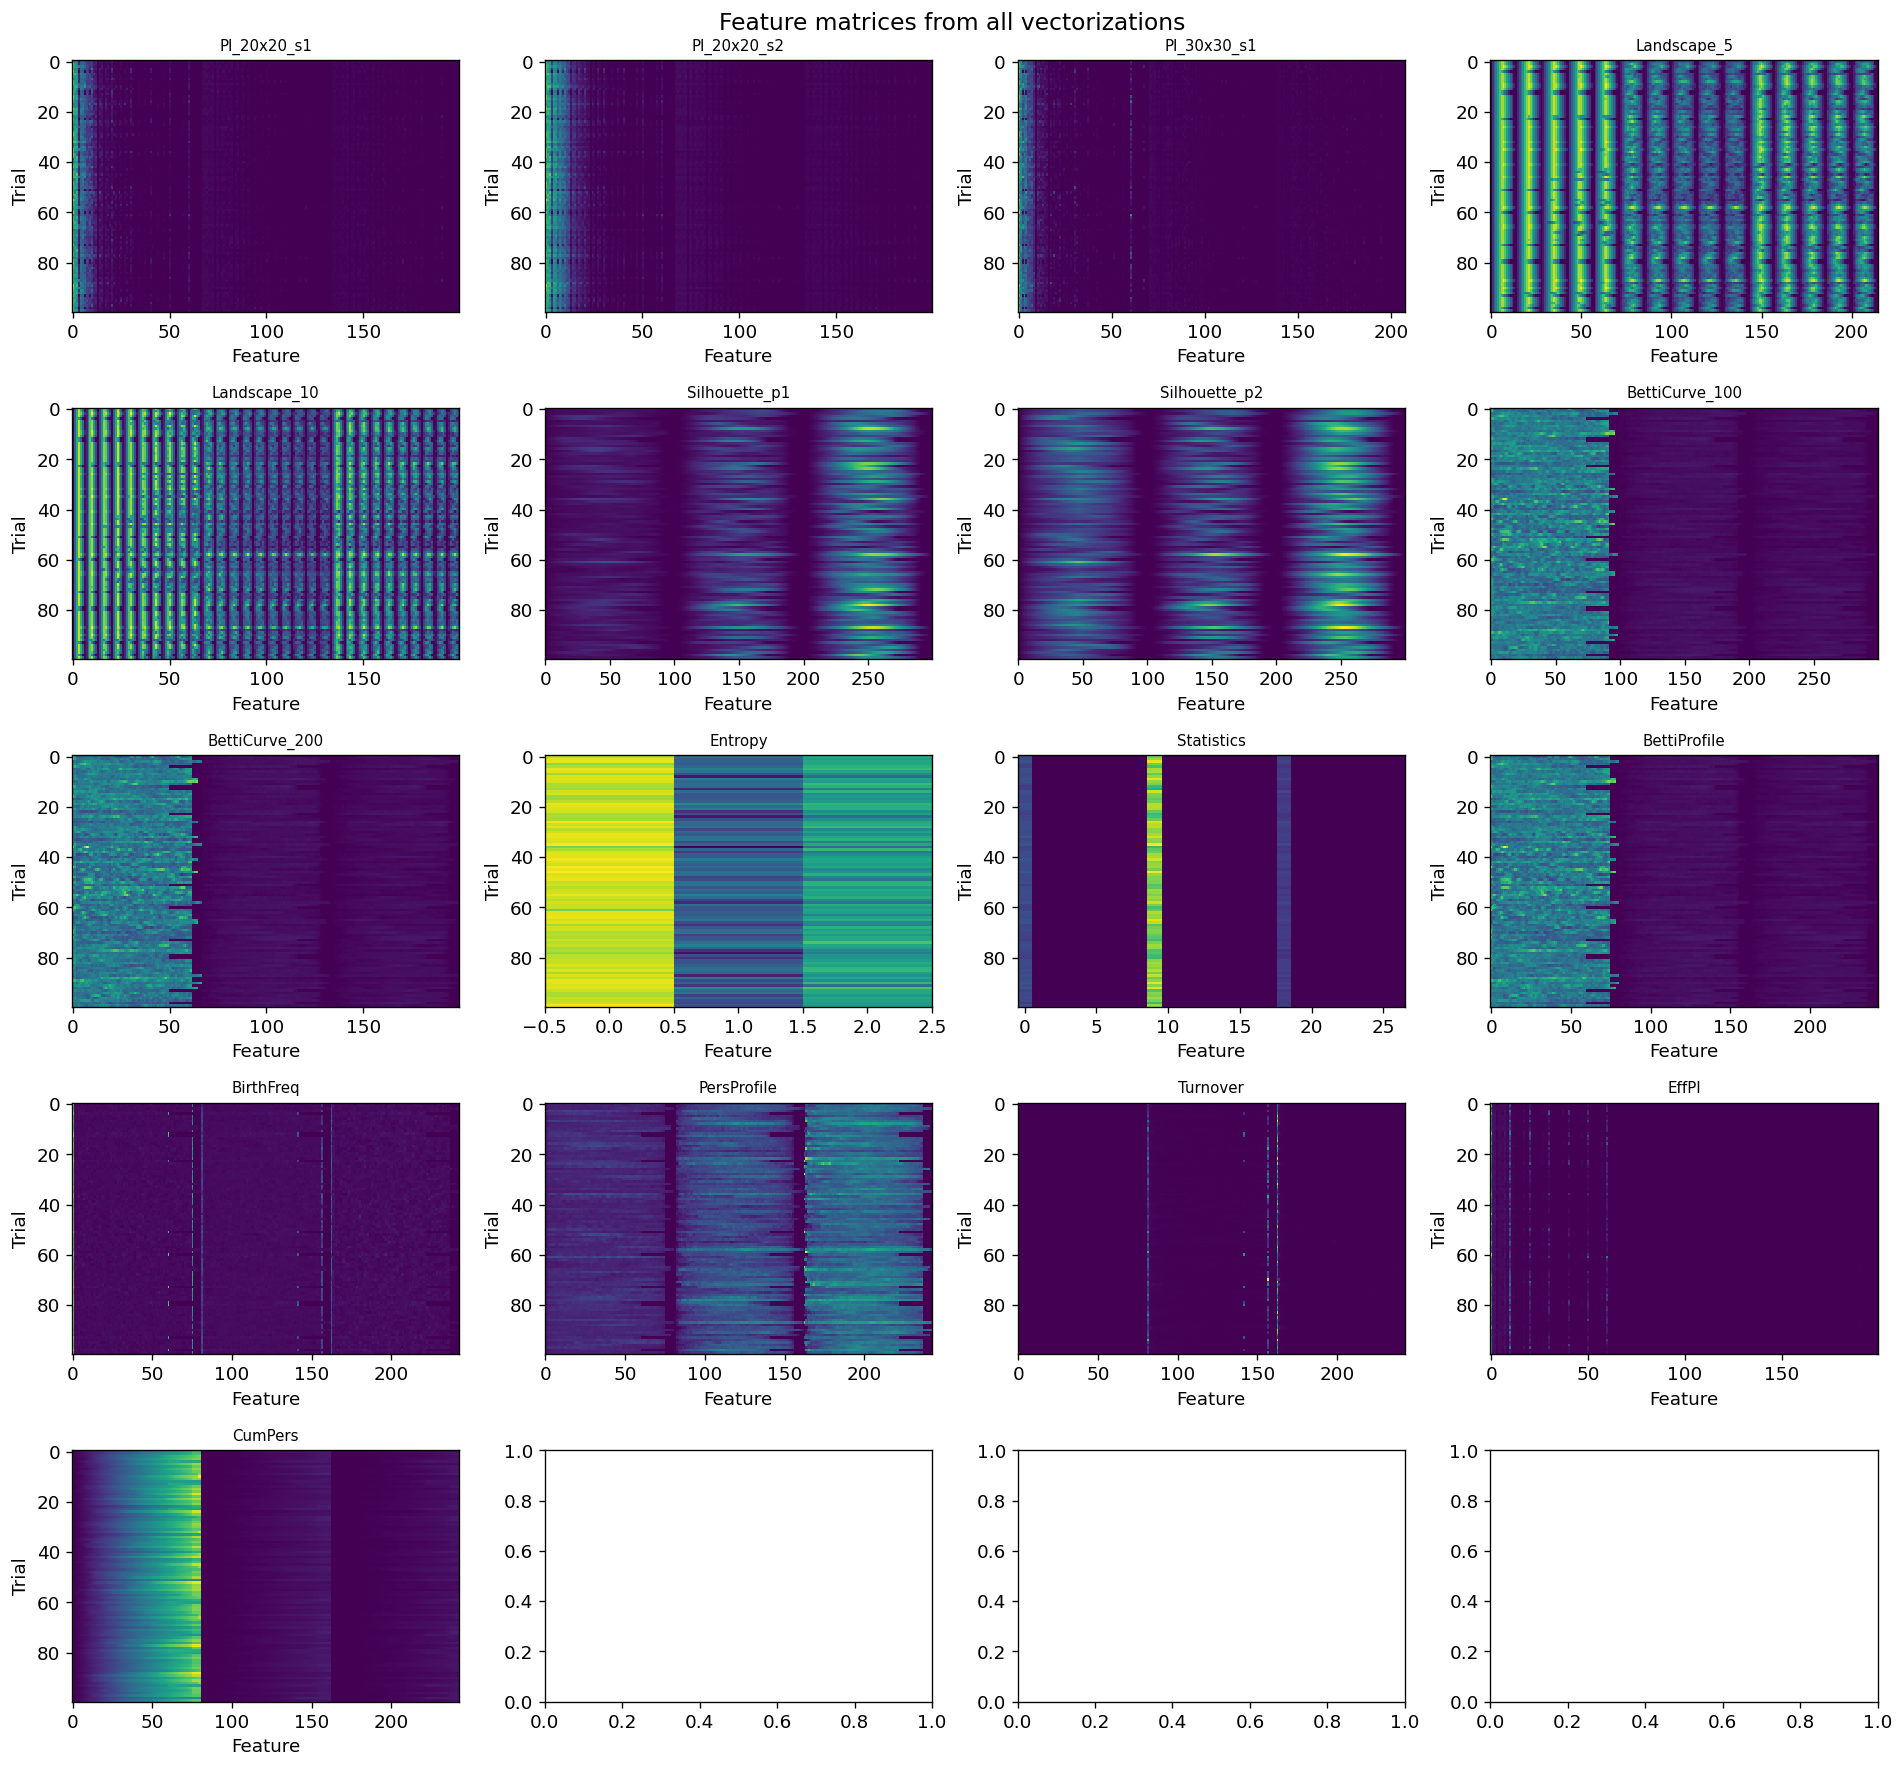

In [7]:
# Heatmaps of feature matrices (rows = trials, columns = features)
n_vecs = len(features)
n_cols = 4
n_rows = (n_vecs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flat

for ax, (name, X) in zip(axes, features.items()):
    # Normalize for display
    X_disp = X.copy()
    X_disp = np.nan_to_num(X_disp)
    if X_disp.shape[1] > 200:
        # Subsample columns for readability
        step = X_disp.shape[1] // 200
        X_disp = X_disp[:, ::step]
    ax.imshow(X_disp, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Trial")

# Hide unused axes
for ax in list(axes)[len(features):]:
    ax.set_visible(False)

fig.suptitle("Feature matrices from all vectorizations", fontsize=14)
plt.tight_layout()
plt.show()

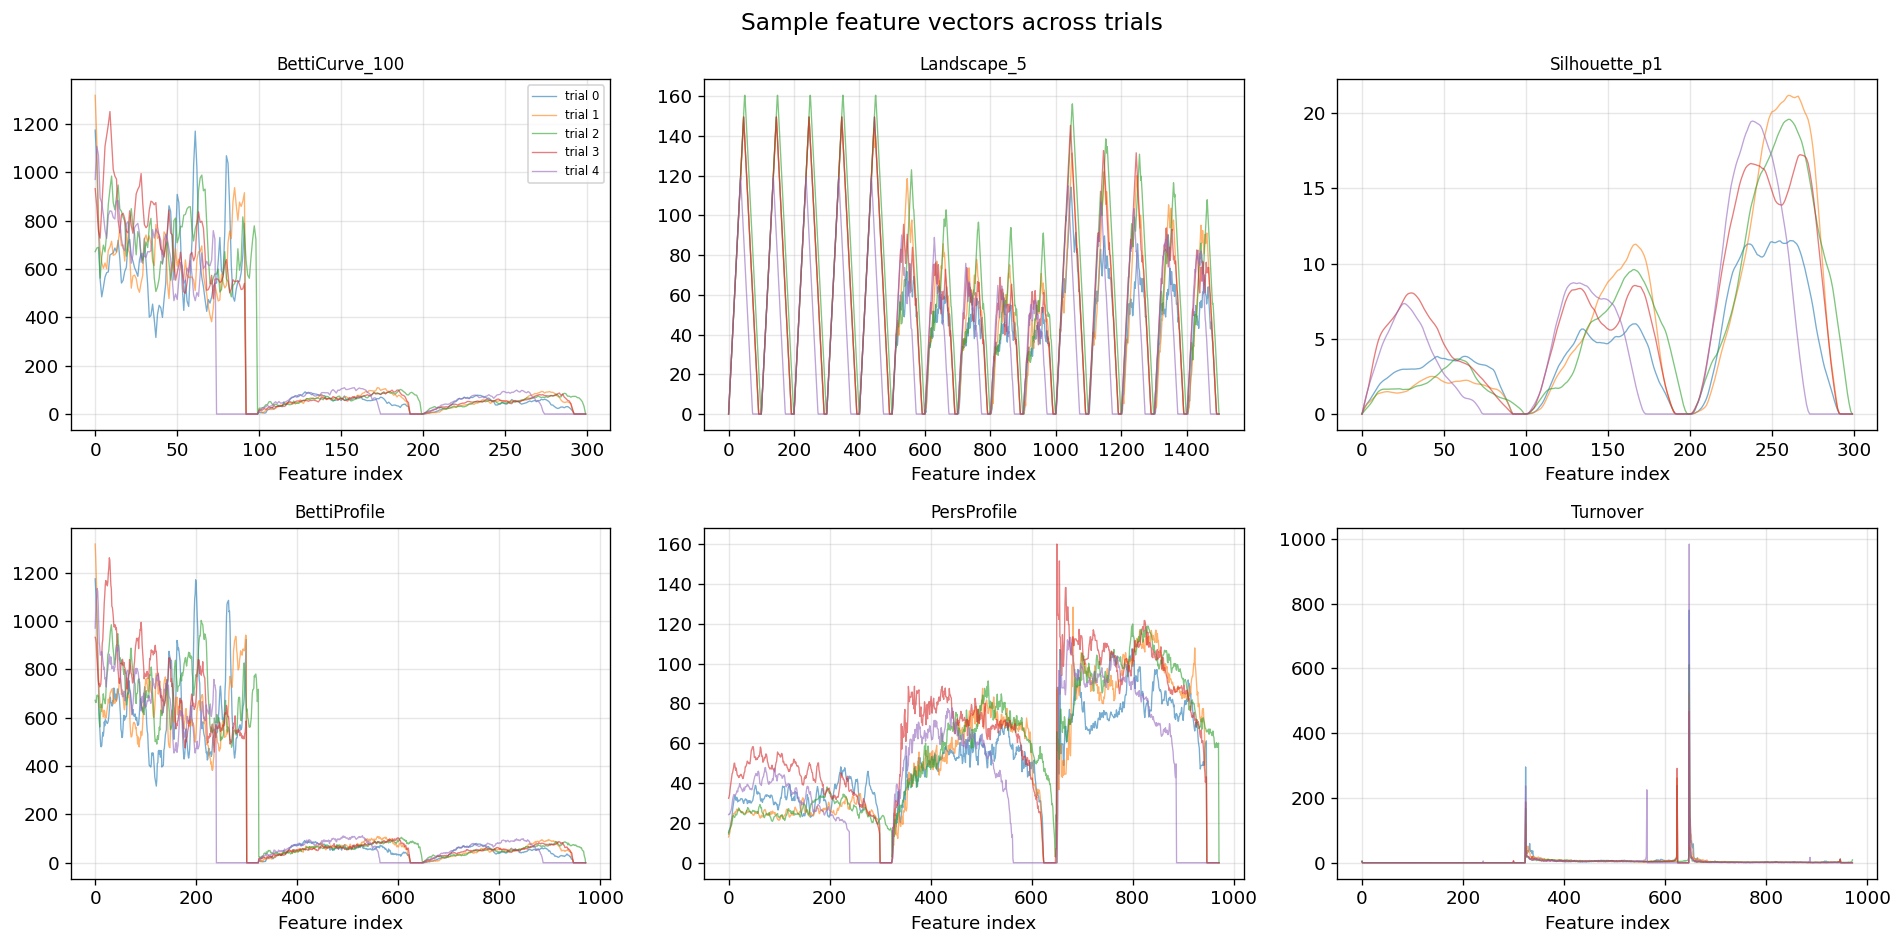

In [8]:
# Overlay a few trials' feature vectors for selected vectorizations
selected_vecs = ["BettiCurve_100", "Landscape_5", "Silhouette_p1",
                 "BettiProfile", "PersProfile", "Turnover"]
n_show = min(5, len(barcodes))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, vname in zip(axes.flat, selected_vecs):
    if vname not in features:
        ax.set_visible(False)
        continue
    X = features[vname]
    for i in range(n_show):
        ax.plot(X[i], alpha=0.6, linewidth=0.8, label=f"trial {i}")
    ax.set_title(vname, fontsize=10)
    ax.set_xlabel("Feature index")
    ax.grid(alpha=0.3)
    if vname == selected_vecs[0]:
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Sample feature vectors across trials", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Inter-trial similarity

Compute pairwise distance matrices (cosine) for each vectorization.
This reveals which vectorizations capture trial-to-trial variability.

In [9]:
# Pairwise cosine distance matrices
distance_matrices = {}

for name, X in features.items():
    X_clean = np.nan_to_num(X)
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    X_scaled = np.nan_to_num(X_scaled)
    
    # Handle zero-variance columns
    norms = np.linalg.norm(X_scaled, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    X_normed = X_scaled / norms
    
    try:
        D = squareform(pdist(X_normed, metric="cosine"))
        D = np.nan_to_num(D)
        distance_matrices[name] = D
    except Exception as e:
        print(f"  {name}: distance computation failed — {e}")

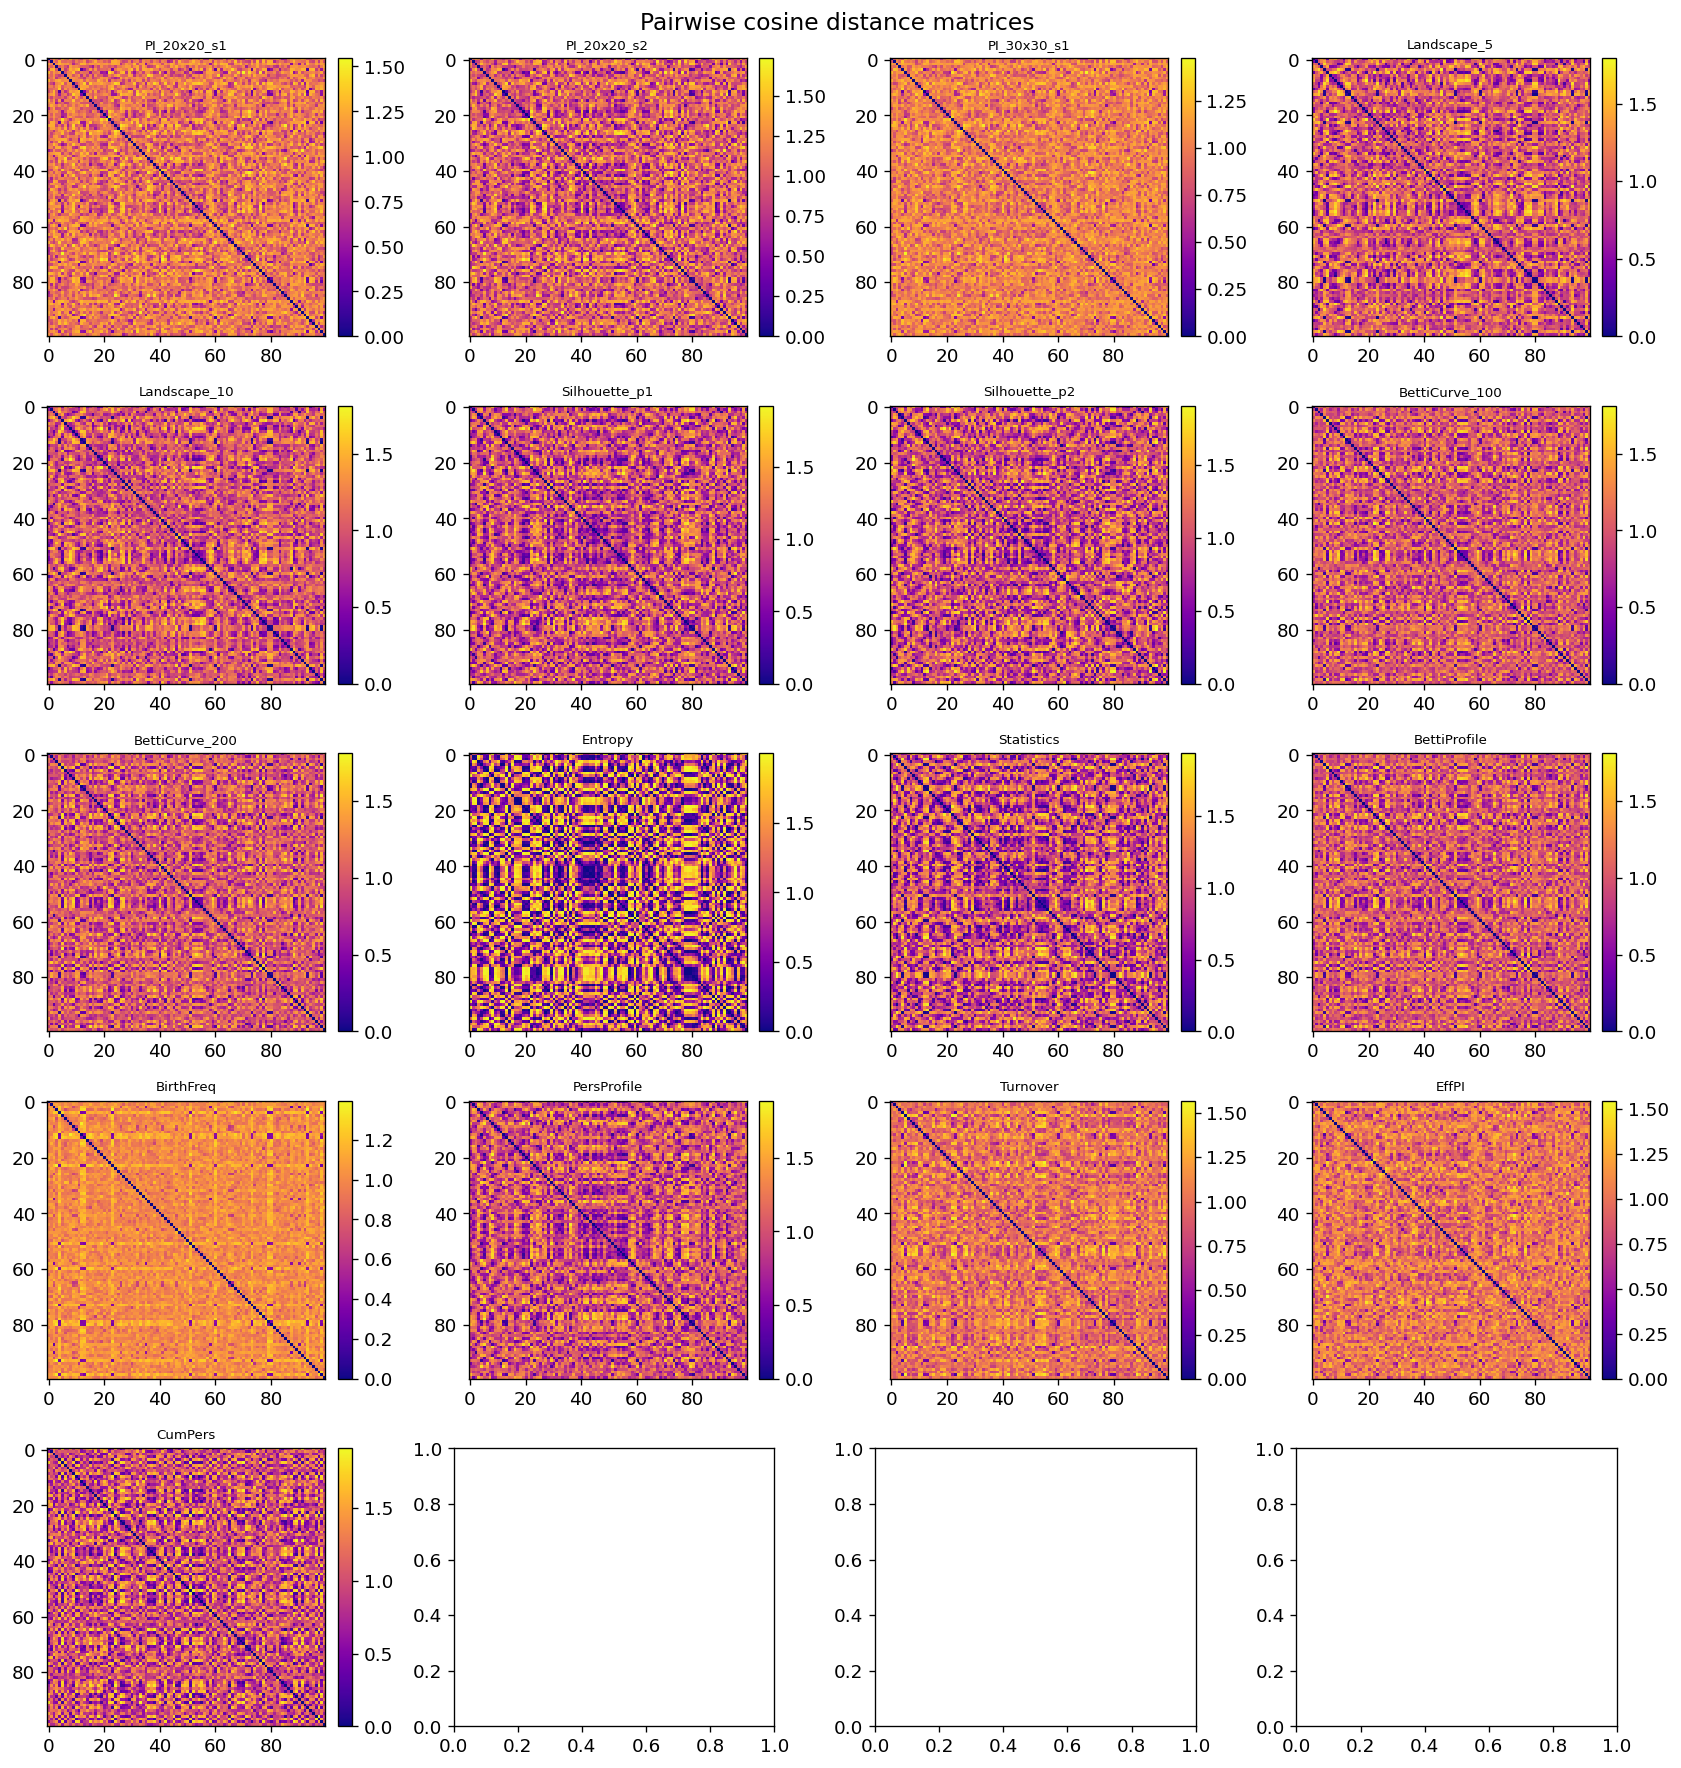

In [10]:
# Plot distance matrices
n_dm = len(distance_matrices)
n_cols = 4
n_rows = (n_dm + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows))
axes_flat = axes.flat if hasattr(axes, "flat") else [axes]

for ax, (name, D) in zip(axes_flat, distance_matrices.items()):
    im = ax.imshow(D, cmap="plasma", vmin=0, interpolation="nearest")
    ax.set_title(name, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in list(axes_flat)[len(distance_matrices):]:
    ax.set_visible(False)

fig.suptitle("Pairwise cosine distance matrices", fontsize=14)
plt.tight_layout()
plt.show()

## 5. PCA exploration

Project each vectorization into 2D via PCA to see if trials separate.

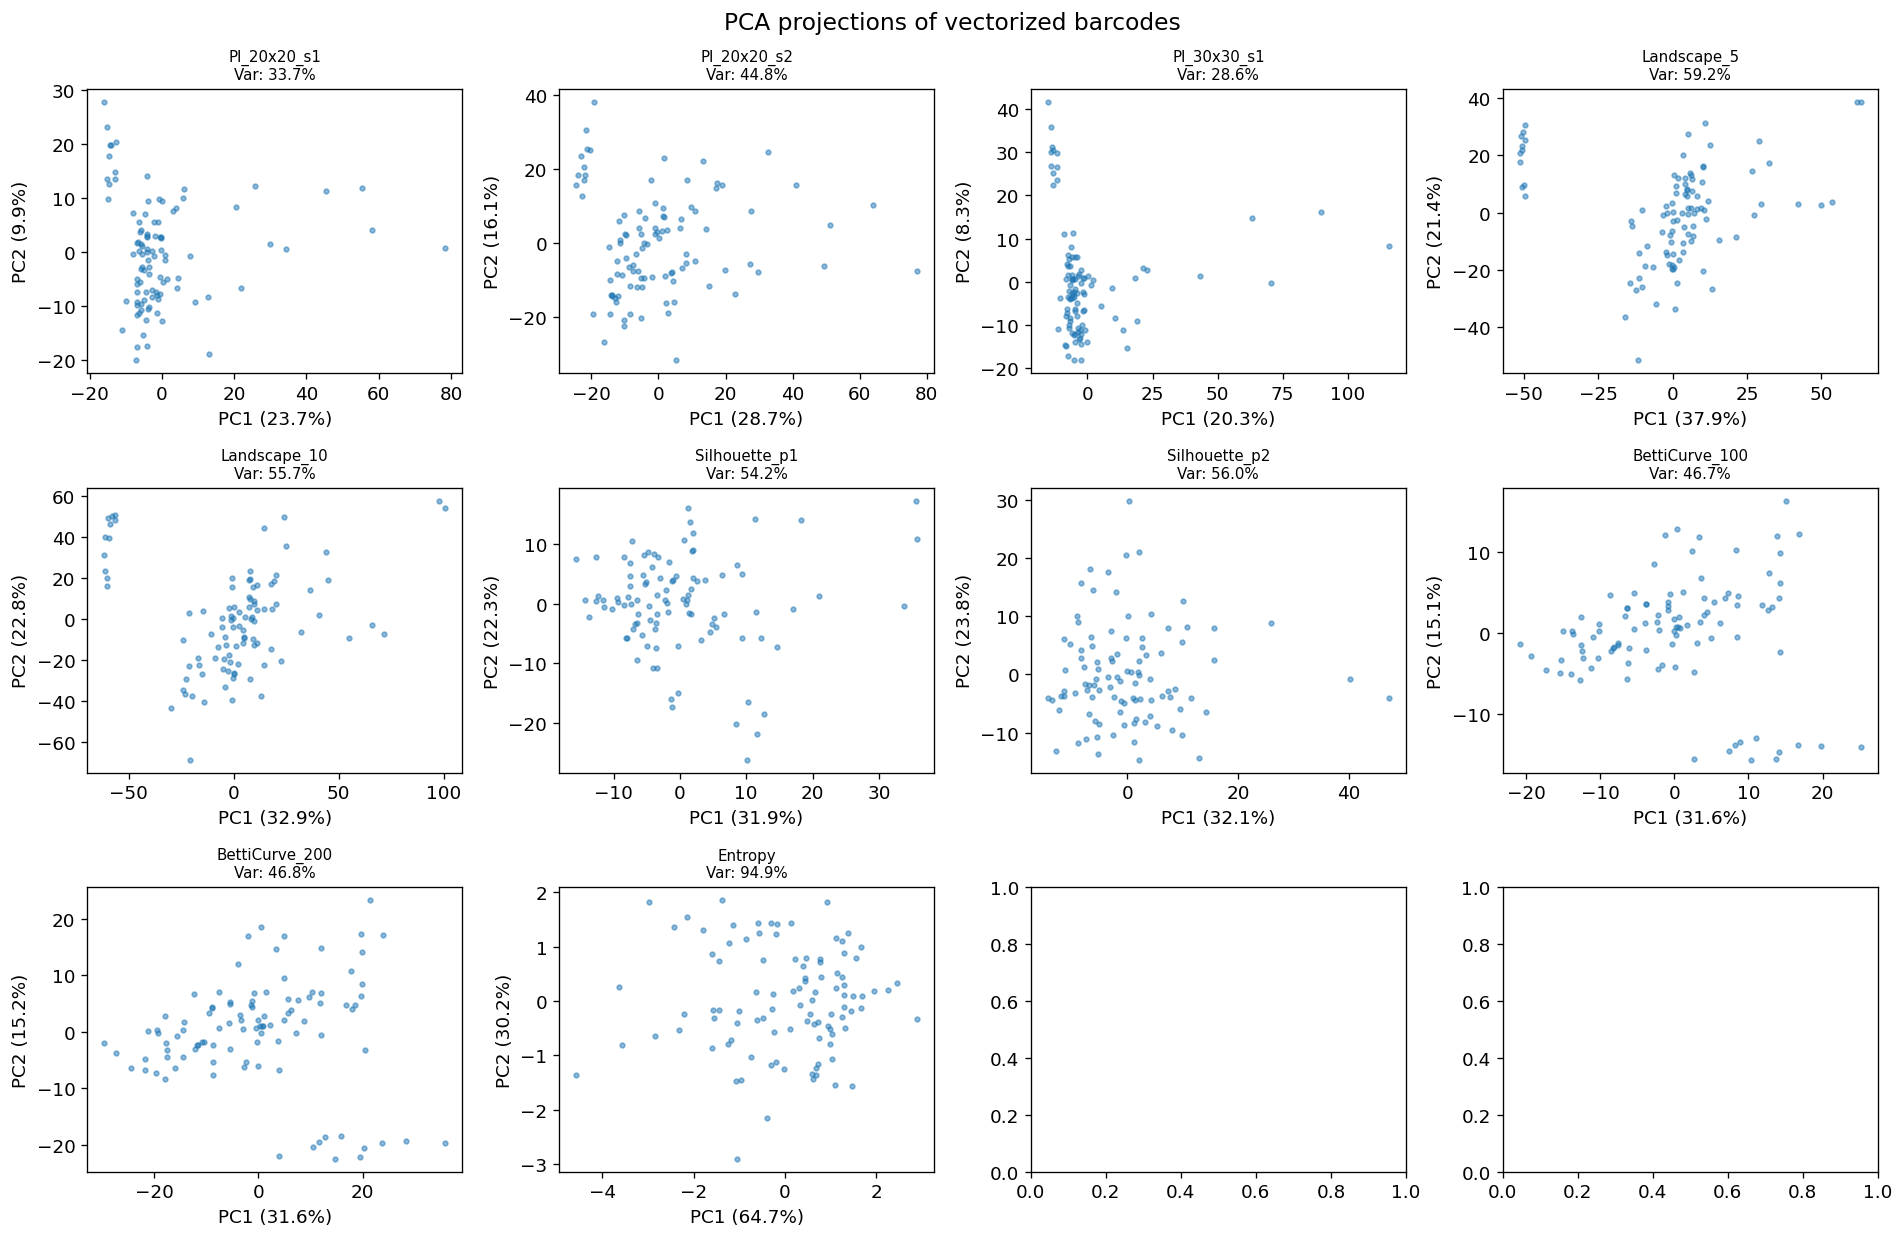

In [11]:
n_vecs = len(features)
n_cols = 4
n_rows = (n_vecs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes_flat = axes.flat

for ax, (name, X) in zip(axes_flat, features.items()):
    X_clean = np.nan_to_num(X)
    if X_clean.shape[1] < 2:
        ax.text(0.5, 0.5, f"{name}\n(1D, skip PCA)", ha="center", va="center",
               transform=ax.transAxes, fontsize=9)
        continue
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    X_scaled = np.nan_to_num(X_scaled)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.5)
    ax.set_title(f"{name}\nVar: {pca.explained_variance_ratio_.sum():.1%}", fontsize=9)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

for ax in list(axes_flat)[n_vecs:]:
    ax.set_visible(False)

fig.suptitle("PCA projections of vectorized barcodes", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Correlation between vectorizations

Identify which vectorizations carry redundant vs. complementary information.

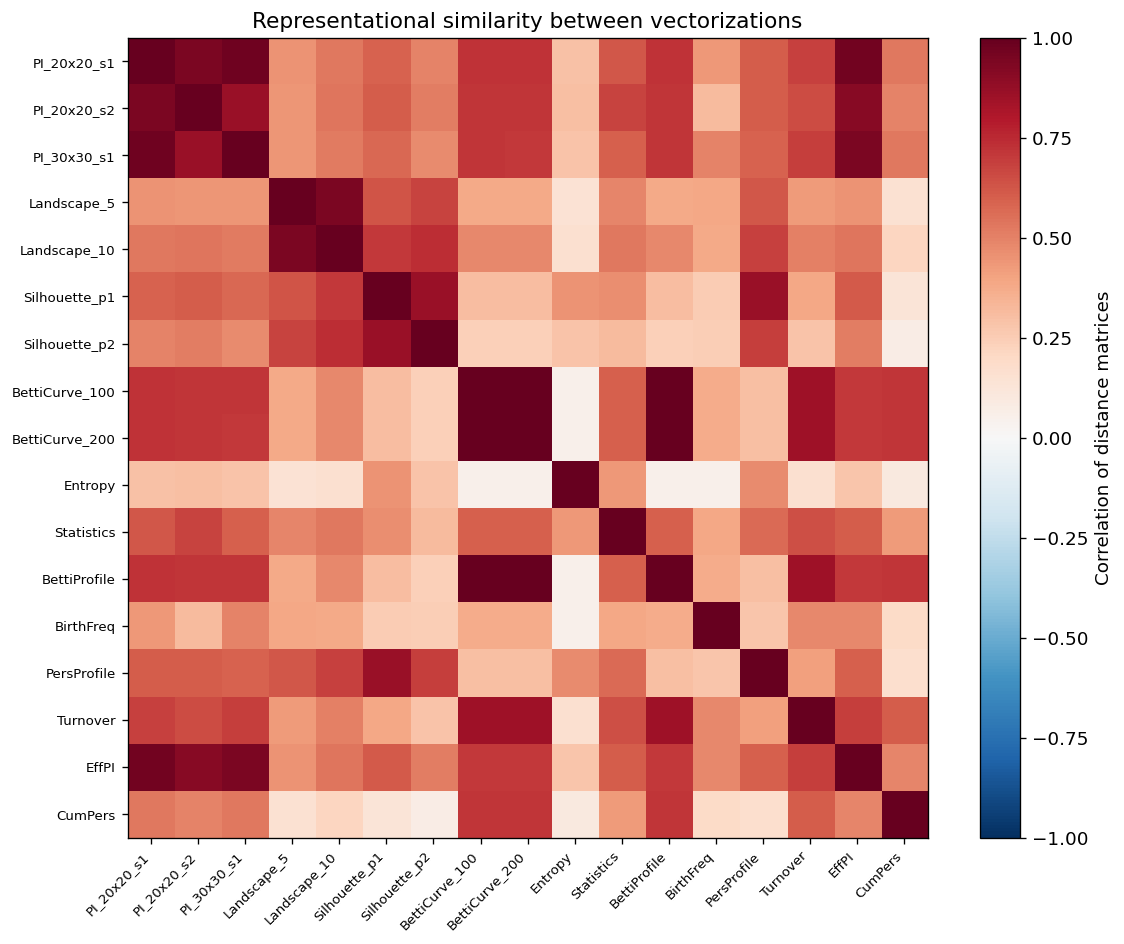

In [11]:
# Compute representational similarity between vectorizations
# using correlation between their pairwise distance matrices
vec_names = list(distance_matrices.keys())
n = len(vec_names)
corr_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        d_i = squareform(distance_matrices[vec_names[i]])
        d_j = squareform(distance_matrices[vec_names[j]])
        corr_matrix[i, j] = np.corrcoef(d_i, d_j)[0, 1]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(vec_names, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(vec_names, fontsize=8)
plt.colorbar(im, ax=ax, label="Correlation of distance matrices")
ax.set_title("Representational similarity between vectorizations", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Preliminary classification test

If labels are available (e.g., different video stimuli, or different mice),
test which vectorization gives the best classification accuracy.

**Proxy task**: Classify trials from 2+ mice. This tests whether the
vectorization captures mouse-specific topological signatures.

In [13]:
# Load barcodes from a second mouse for a 2-class classification task
MOUSE_2 = None
for m in mice:
    if m != REF_MOUSE:
        zz_dir = DATA_ROOT / m / ZZ_FOLDER
        if zz_dir.is_dir() and len(list(zz_dir.glob("*.npy"))) > 10:
            MOUSE_2 = m
            break

if MOUSE_2 is None:
    print("Only one mouse has zigzag results — skipping classification test.")
    print("Re-run this cell after the batch job completes for more mice.")
else:
    print(f"Mouse 1: {REF_MOUSE[:40]}...")
    print(f"Mouse 2: {MOUSE_2[:40]}...")
    
    barcodes_2, _ = load_zigzag_barcodes(MOUSE_2, max_trials=100)
    
    # Combine datasets
    all_barcodes = barcodes + barcodes_2
    labels = np.array([0] * len(barcodes) + [1] * len(barcodes_2))
    print(f"\nCombined: {len(all_barcodes)} barcodes, "
          f"class 0: {(labels==0).sum()}, class 1: {(labels==1).sum()}")

Mouse 1: dynamic29156-11-10-Video-8744edeac3b4d1c...
Mouse 2: dynamic29228-2-10-Video-8744edeac3b4d1ce...

Combined: 200 barcodes, class 0: 100, class 1: 100


In [14]:
# Run classification with each vectorization
if MOUSE_2 is not None:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}
    
    for vname, vec in vectorizers.items():
        try:
            X = vec.fit_transform(all_barcodes)
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = np.nan_to_num(X)
            
            # Simple pipeline: scale + logistic regression
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, random_state=42)),
            ])
            scores = cross_val_score(pipe, X, labels, cv=cv, scoring="accuracy")
            results[vname] = {
                "mean_acc": scores.mean(),
                "std_acc": scores.std(),
                "n_features": X.shape[1],
            }
            print(f"  {vname:>20s}: acc={scores.mean():.3f} ± {scores.std():.3f} "
                  f"(n_feat={X.shape[1]})")
        except Exception as e:
            print(f"  {vname:>20s}: FAILED — {e}")
else:
    print("Skipped — need 2+ mice with results.")

           PI_20x20_s1: acc=0.800 ± 0.071 (n_feat=1200)
           PI_20x20_s2: acc=0.860 ± 0.054 (n_feat=1200)
           PI_30x30_s1: acc=0.800 ± 0.088 (n_feat=2700)
           Landscape_5: acc=0.890 ± 0.020 (n_feat=1500)


KeyboardInterrupt: 

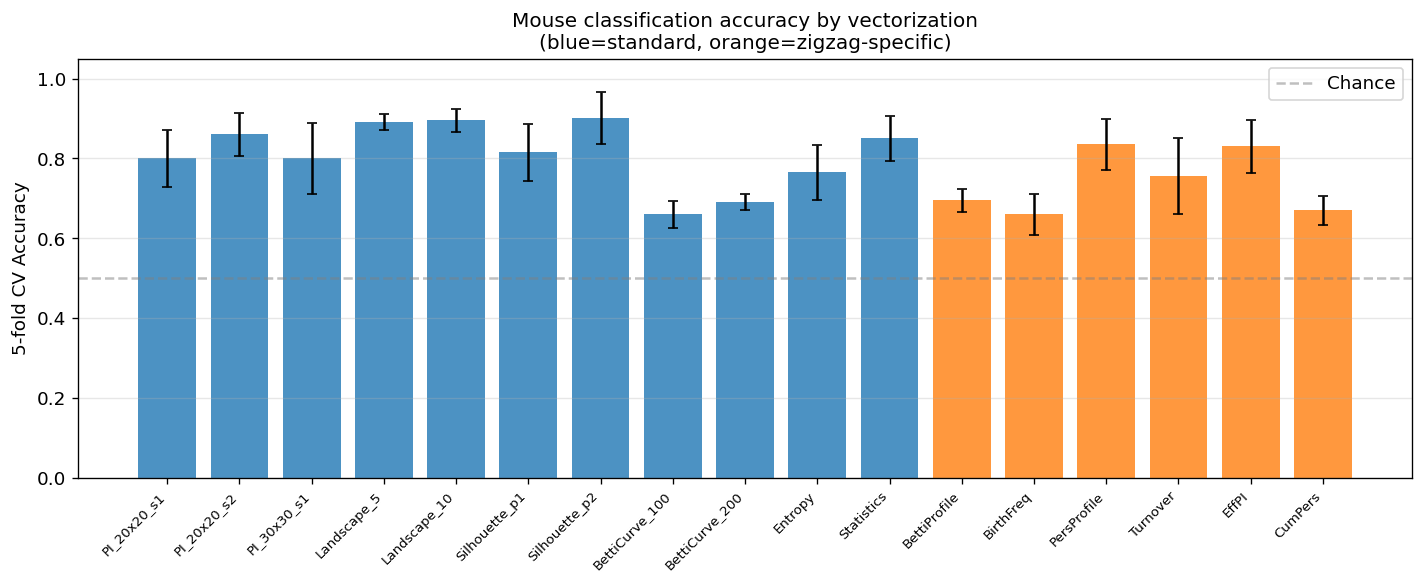

In [ ]:
# Bar chart of classification accuracies
if MOUSE_2 is not None and results:
    names = list(results.keys())
    accs = [results[n]["mean_acc"] for n in names]
    stds = [results[n]["std_acc"] for n in names]
    
    # Color: standard = blue, zigzag-specific = orange
    zz_specific = {"BettiProfile", "BirthFreq", "PersProfile",
                   "Turnover", "EffPI", "CumPers"}
    colors = ["tab:orange" if n in zz_specific else "tab:blue" for n in names]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(range(len(names)), accs, yerr=stds, color=colors,
                  capsize=3, alpha=0.8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("5-fold CV Accuracy")
    ax.set_title("Mouse classification accuracy by vectorization\n"
                f"(blue=standard, orange=zigzag-specific)", fontsize=12)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7b. Within-mouse video-stimulus classification

Each trial was recorded while the mouse viewed one of **six** visual stimulus
types (each mouse sees NaturalVideo + 3 others):

| Stimulus | Frames | Notes |
|---|---|---|
| **NaturalVideo** | 300 | natural movie clips (all mice) |
| **NaturalImages** | 305–414 | static natural images, variable length |
| **Gabor** | 300 | Gabor gratings |
| **GaussianDot** | 315 | moving Gaussian dot |
| **RandomDots** | 240 | random dot kinematograms |
| **PinkNoise** | 324 | pink noise sequences |

This is a more scientifically meaningful test: **can the topological summary
of neural activity distinguish which stimulus the mouse was viewing?**

Labels come from the [sensorium metadata](https://github.com/anaflom/sensorium)
(`meta-trials_<recording>.csv`).

> **Handling variable trial lengths.** Stimuli differ in duration (240–414
> frames). To prevent classifiers from trivially distinguishing stimulus types
> by detecting trailing zeros, we **truncate** all barcodes to the shortest
> trial length (`min(valid_frames)` from metadata). Bars born after the cutoff
> are dropped; bars that extend past it are clipped. This ensures the classifier
> can only use the topological representation of neural activity — not the
> recording length — to discriminate stimuli.

In [14]:
import pandas as pd
import re

# ── Path to the sensorium metadata repo (cloned from anaflom/sensorium) ────
META_ROOT = Path("/u/area/mbiagetti/Codes/sensorium_metadata/metadata")

def load_trial_metadata(mouse_name):
    """Load the meta-trials CSV for a recording and return a DataFrame."""
    csv_path = (META_ROOT / mouse_name / "trials"
                / f"meta-trials_{mouse_name}.csv")
    if not csv_path.exists():
        raise FileNotFoundError(f"Metadata not found: {csv_path}")
    df = pd.read_csv(csv_path)
    return df

def load_labelled_barcodes(mouse_name):
    """Load ALL barcodes for a mouse and attach stimulus labels + frame counts.
    
    Returns
    -------
    barcodes     : list of list-of-tuples  (dim, birth, death)
    labels       : np.ndarray of str       (e.g. 'NaturalVideo')
    trial_ids    : list of int
    valid_frames : np.ndarray of int       (number of frames per trial)
    """
    df = load_trial_metadata(mouse_name)
    trial_to_label  = dict(zip(df["trial"].astype(int), df["label"]))
    trial_to_frames = dict(zip(df["trial"].astype(int), df["valid_frames"].astype(int)))
    
    zz_dir = DATA_ROOT / mouse_name / ZZ_FOLDER
    files = sorted(zz_dir.glob("zz-thresh-*.npy"))
    files = [f for f in files if "info" not in f.name]
    
    barcodes, labels_list, trial_ids, frames_list = [], [], [], []
    for f in files:
        # Extract trial number from filename: zz-thresh-30_trial-123.npy
        match = re.search(r"trial-(\d+)", f.stem)
        if match is None:
            continue
        trial_num = int(match.group(1))
        if trial_num not in trial_to_label:
            continue
        
        raw = np.load(f, allow_pickle=True)
        bars = [tuple(row) for row in raw]
        barcodes.append(bars)
        labels_list.append(trial_to_label[trial_num])
        trial_ids.append(trial_num)
        frames_list.append(trial_to_frames[trial_num])
    
    return barcodes, np.array(labels_list), trial_ids, np.array(frames_list)

# ── Load ────────────────────────────────────────────────────────────────────
stim_barcodes, stim_labels, stim_trial_ids, stim_valid_frames = \
    load_labelled_barcodes(REF_MOUSE)

print(f"Mouse: {REF_MOUSE[:50]}...")
print(f"Total matched trials: {len(stim_barcodes)}")
unique, counts = np.unique(stim_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:>15s}: {c:>4d} trials")
print(f"\nValid-frames range: {stim_valid_frames.min()} – {stim_valid_frames.max()}")

Mouse: dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916...
Total matched trials: 720
      GaussianDot:   59 trials
     NaturalVideo:  523 trials
        PinkNoise:   59 trials
       RandomDots:   79 trials

Valid-frames range: 240 – 324


In [ ]:
# ── Truncate barcodes to shortest trial so classification is fair ────────────
# Using min(valid_frames) ensures no trial gets zero-padded; the classifier
# can only rely on the topological structure within the common time window.
CLIP_FRAMES = int(stim_valid_frames.min())
print(f"Clipping all barcodes to {CLIP_FRAMES} frames "
      f"(shortest stimulus: {CLIP_FRAMES})")

def clip_barcodes(barcodes, n_frames):
    """Clip barcodes to a time window [0, n_frames).
    
    - Bars born at or after n_frames are dropped.
    - Bars whose death exceeds n_frames are clipped to n_frames.
    """
    clipped = []
    for bars in barcodes:
        new_bars = []
        for dim, b, d in bars:
            if b >= n_frames:
                continue  # born outside window → drop
            new_bars.append((dim, b, min(d, n_frames)))
        clipped.append(new_bars)
    return clipped

stim_barcodes_clipped = clip_barcodes(stim_barcodes, CLIP_FRAMES)

# Sanity check: show how many bars survived per label
for label in sorted(set(stim_labels)):
    mask = stim_labels == label
    orig = sum(len(b) for b, m in zip(stim_barcodes, mask) if m)
    clip = sum(len(b) for b, m in zip(stim_barcodes_clipped, mask) if m)
    print(f"  {label:>15s}: {orig:>6d} bars → {clip:>6d} after clipping "
          f"({100*clip/orig:.1f}%)")

# ── Pre-normalise to DiagramDict once (huge speed-up) ───────────────────────
# Each vectorizer internally converts list-of-tuples → {dim: ndarray} via a
# slow Python loop.  By doing this conversion once and re-using the dict
# representation, we avoid repeating it for every vectorizer (12×).
from zztop.vectorizations._diagram import normalize_diagram

print("\nPre-normalising clipped barcodes to DiagramDict …")
stim_diagrams = [normalize_diagram(b, drop_inf=True) for b in stim_barcodes_clipped]
print(f"Done — {len(stim_diagrams)} diagrams ready.")

# ── Build vectorizers ────────────────────────────────────────────────────────
stim_vectorizers = {
    # Standard (resolution-based — not affected by n_frames)
    "PersImage":   PersistenceImage(resolution=(20, 20)),
    "Landscape":   PersistenceLandscape(resolution=100, n_landscapes=5),
    "Silhouette":  Silhouette(resolution=100),
    "BettiCurve":  BettiCurve(resolution=100),
    "PersEntropy": PersistenceEntropy(),
    "PersStats":   PersistenceStatistics(),
    # Zigzag-specific (n_frames = CLIP_FRAMES → no zero-padding)
    "BettiProfile": BettiProfile(n_frames=CLIP_FRAMES),
    "BirthFreq":    BirthFrequency(n_frames=CLIP_FRAMES),
    "PersProfile":  PersistenceProfile(n_frames=CLIP_FRAMES),
    "Turnover":     TurnoverRate(n_frames=CLIP_FRAMES),
    "EffPI":        EffectivePersistenceImage(n_frames=CLIP_FRAMES),
    "CumPers":      CumulativePersistence(n_frames=CLIP_FRAMES),
}

# ── Multi-class classification ──────────────────────────────────────────────
from sklearn.model_selection import cross_validate

cv_stim = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"acc": "accuracy", "f1": "f1_macro"}

stim_results = {}
for vname, vec in stim_vectorizers.items():
    try:
        X = vec.fit_transform(stim_diagrams)       # uses pre-normalised dicts
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        X = np.nan_to_num(X)
        
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000, random_state=42,
                class_weight="balanced",
            )),
        ])
        cv_res = cross_validate(pipe, X, stim_labels, cv=cv_stim,
                                scoring=scoring)
        acc_scores = cv_res["test_acc"]
        f1_scores  = cv_res["test_f1"]
        stim_results[vname] = {
            "mean_acc": acc_scores.mean(),
            "std_acc":  acc_scores.std(),
            "mean_f1":  f1_scores.mean(),
            "std_f1":   f1_scores.std(),
            "n_features": X.shape[1],
        }
        print(f"  {vname:>15s}: acc={acc_scores.mean():.3f}±{acc_scores.std():.3f}  "
              f"F1={f1_scores.mean():.3f}±{f1_scores.std():.3f}  "
              f"(n_feat={X.shape[1]})")
    except Exception as e:
        print(f"  {vname:>15s}: FAILED — {e}")

Clipping all barcodes to 240 frames (shortest stimulus: 240)


      GaussianDot: 9598577 bars → 7313798 after clipping (76.2%)
     NaturalVideo: 76281440 bars → 59874472 after clipping (78.5%)
        PinkNoise: 10031605 bars → 7373685 after clipping (73.5%)
       RandomDots: 9446664 bars → 9138914 after clipping (96.7%)

Pre-normalising clipped barcodes to DiagramDict …
Done — 720 diagrams ready.


/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator,

        PersImage: acc=0.829±0.021  F1=nan±nan  (n_feat=1200)


/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator,

...

/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator,

            EffPI: acc=0.844±0.012  F1=nan±nan  (n_feat=1200)


/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator,

          CumPers: acc=0.782±0.036  F1=nan±nan  (n_feat=720)


/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "/u/area/mbiagetti/Codes/ZigZagComplexNeural/.venv/lib64/python3.13/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator,

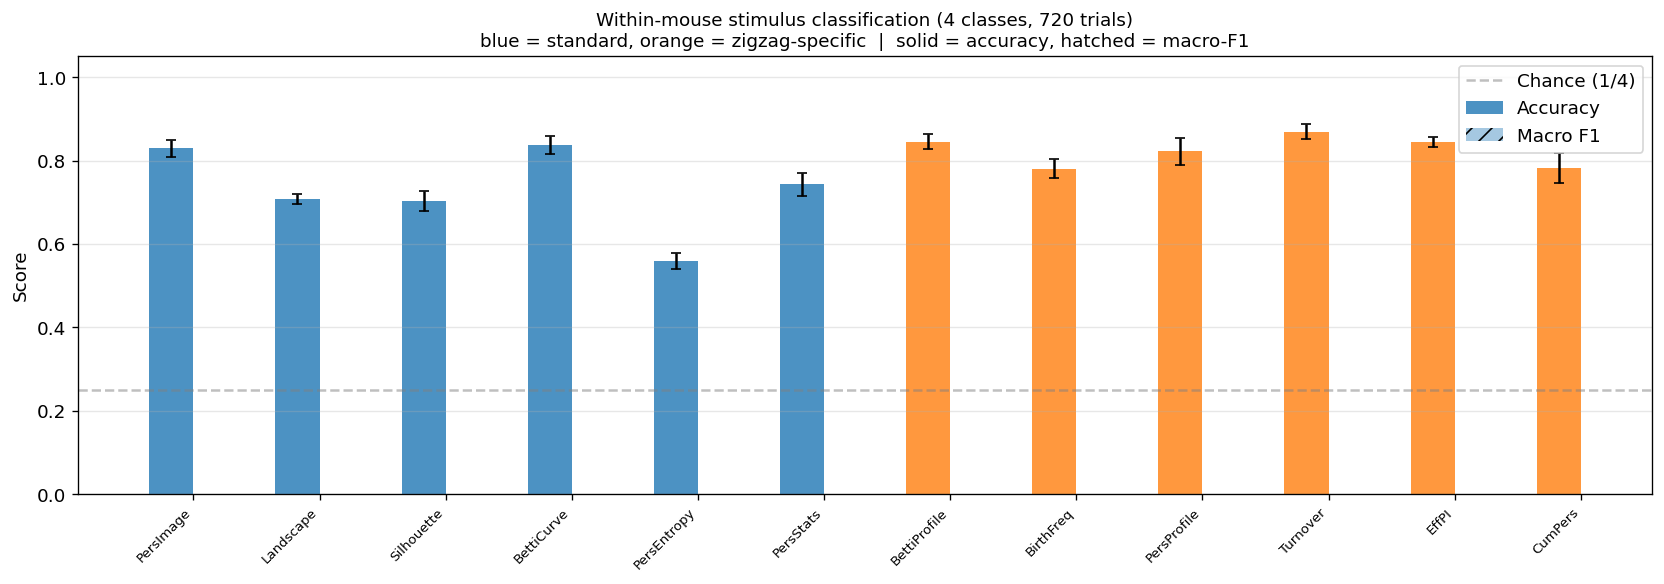

In [16]:
# ── Bar chart: within-mouse stimulus classification ─────────────────────────
if stim_results:
    names = list(stim_results.keys())
    accs  = [stim_results[n]["mean_acc"] for n in names]
    a_err = [stim_results[n]["std_acc"]  for n in names]
    f1s   = [stim_results[n]["mean_f1"]  for n in names]
    f_err = [stim_results[n]["std_f1"]   for n in names]
    
    zz_specific = {"BettiProfile", "BirthFreq", "PersProfile",
                   "Turnover", "EffPI", "CumPers"}
    colors = ["tab:orange" if n in zz_specific else "tab:blue" for n in names]
    
    x = np.arange(len(names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, accs, width, yerr=a_err, color=colors,
           capsize=3, alpha=0.8, label="Accuracy")
    ax.bar(x + width/2, f1s,  width, yerr=f_err, color=colors,
           capsize=3, alpha=0.4, hatch="//", label="Macro F1")
    
    # Chance line
    n_classes = len(np.unique(stim_labels))
    ax.axhline(1.0 / n_classes, color="gray", ls="--", alpha=0.5,
               label=f"Chance (1/{n_classes})")
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title(
        f"Within-mouse stimulus classification ({n_classes} classes, "
        f"{len(stim_barcodes)} trials)\n"
        f"blue = standard, orange = zigzag-specific  |  "
        f"solid = accuracy, hatched = macro-F1",
        fontsize=11,
    )
    ax.legend(loc="upper right")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

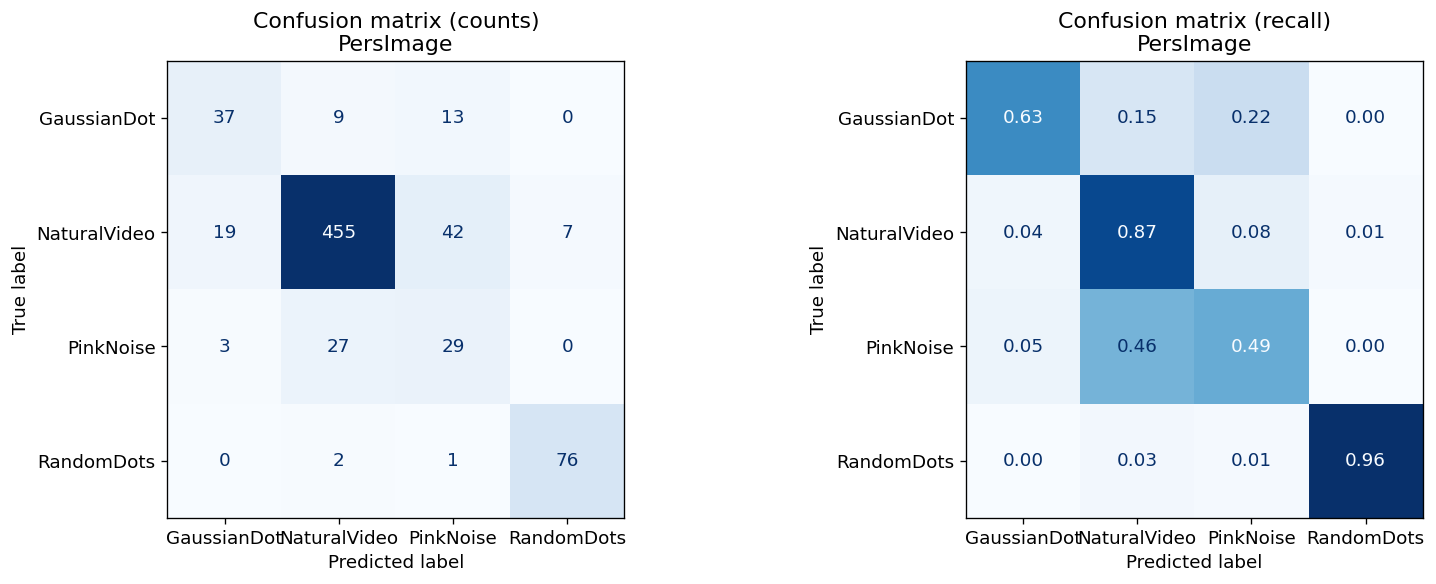


Best vectorizer by macro-F1: PersImage (F1=nan)


In [17]:
# ── Confusion matrix for the best vectorizer ────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if stim_results:
    best_name = max(stim_results, key=lambda k: stim_results[k]["mean_f1"])
    best_vec  = stim_vectorizers[best_name]
    
    X_best = best_vec.fit_transform(stim_diagrams)
    if X_best.ndim == 1:
        X_best = X_best.reshape(-1, 1)
    X_best = np.nan_to_num(X_best)
    
    pipe_best = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000, random_state=42,
            class_weight="balanced",
        )),
    ])
    
    # Collect predictions across all folds
    from sklearn.model_selection import cross_val_predict
    y_pred = cross_val_predict(pipe_best, X_best, stim_labels,
                               cv=cv_stim)
    
    class_order = sorted(np.unique(stim_labels))
    cm = confusion_matrix(stim_labels, y_pred, labels=class_order)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    ConfusionMatrixDisplay(cm, display_labels=class_order).plot(
        ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"Confusion matrix (counts)\n{best_name}")
    
    # Normalised by true label
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_norm, display_labels=class_order).plot(
        ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
    axes[1].set_title(f"Confusion matrix (recall)\n{best_name}")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBest vectorizer by macro-F1: {best_name} "
          f"(F1={stim_results[best_name]['mean_f1']:.3f})")

## 8. Summary and recommendations

Evaluate each vectorization along the following axes:
1. **Feature dimensionality** — lower is better for efficiency
2. **Inter-trial variability** — should capture meaningful differences
3. **Classification accuracy** — proxy for discriminative power
4. **Complementarity** — low correlation with other vectorizations = complementary info
5. **Interpretability** — temporal vectorizations (zigzag-specific) are more interpretable

In [18]:
# Summary table
print(f"{'Vectorization':>20s} | {'Dims':>6s} | {'Dist spread':>12s} | "
      f"{'Mouse acc':>10s} | {'Stim F1':>10s} | {'Type':>10s}")
print("-" * 90)

zz_specific = {"BettiProfile", "BirthFreq", "PersProfile",
               "Turnover", "EffPI", "CumPers"}

for name in features:
    n_feat = features[name].shape[1]
    
    # Distance spread (std of pairwise distances)
    if name in distance_matrices:
        D = distance_matrices[name]
        d_spread = f"{np.std(squareform(D)):.4f}"
    else:
        d_spread = "N/A"
    
    # Cross-mouse accuracy
    if MOUSE_2 is not None and name in results:
        acc = f"{results[name]['mean_acc']:.3f}"
    else:
        acc = "N/A"
    
    # Within-mouse stimulus F1
    if name in stim_results:
        stim_f1 = f"{stim_results[name]['mean_f1']:.3f}"
    else:
        stim_f1 = "N/A"
    
    vtype = "zigzag" if name in zz_specific else "standard"
    
    print(f"{name:>20s} | {n_feat:>6d} | {d_spread:>12s} | {acc:>10s} | {stim_f1:>10s} | {vtype:>10s}")

print("\n" + "=" * 90)
print("RECOMMENDATION: Choose vectorization(s) with:")
print("  - High stimulus-classification F1 (within-mouse discriminative power)")
print("  - High cross-mouse accuracy (captures mouse-specific signatures)")
print("  - Moderate feature dimensionality")
print("  - Low redundancy with other chosen vectorizations")
print("  - Consider combining one standard + one zigzag-specific vectorization")

       Vectorization |   Dims |  Dist spread |  Mouse acc |    Stim F1 |       Type
------------------------------------------------------------------------------------------


NameError: name 'MOUSE_2' is not defined